In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset, concatenate_datasets
from transformers import AutoProcessor, CLIPModel
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm


### 1. CONFIG

In [16]:
# Dataset paths
DATIKZ_DIR = Path("/home/jonas/Datasets/TikZ/DatikZ-v4")
BENCHMARK_DIR = Path("/home/jonas/Datasets/TikZ/benchmark-not-clean")

# Choose one or both datasets:
# ("datikz",)
# ("benchmark",)
# ("datikz", "benchmark")
DATASETS_TO_USE = ("datikz", "benchmark")

# Input schemas
DATIKZ_IMAGE_COL = "png_image"
DATIKZ_ID_COL = "file_id"
DATIKZ_SOURCE_COL = "source"

BENCHMARK_IMAGE_COL = "image"
BENCHMARK_ID_COL = "uri"
BENCHMARK_SOURCE_COL = "origin"

# None uses the complete dataset. Sampling is applied per dataset.
N_SAMPLES_DATIKZ = None
N_SAMPLES_BENCHMARK = None

N_CLUSTERS = 4
BATCH_SIZE = 128
SEED = 42

IMAGE_COL = "image"  # Canonical image column after normalization.
MODEL_ID = "openai/clip-vit-base-patch32"

OUTPUT_PREFIX = "_".join(DATASETS_TO_USE)


### 2. LOAD DATA

Each selected dataset is normalized to the same temporary schema. Set
`DATASETS_TO_USE` to `("datikz",)`, `("benchmark",)`, or
`("datikz", "benchmark")`. When both are enabled, their rows are concatenated
only for embedding and clustering. The `dataset` column preserves the origin
of every sample.


In [17]:
def load_local_dataset(path: Path):
    parquet_files = sorted(path.rglob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {path}")

    return load_dataset(
        "parquet",
        data_files=[str(path) for path in parquet_files],
        split="train",
    )


def normalize_dataset(
    dataset,
    dataset_name: str,
    image_col: str,
    id_col: str,
    source_col: str,
):
    required = {image_col, id_col, source_col}
    missing = required - set(dataset.column_names)
    if missing:
        raise ValueError(
            f"{dataset_name} is missing required columns: {sorted(missing)}"
        )

    if image_col != IMAGE_COL:
        dataset = dataset.rename_column(image_col, IMAGE_COL)

    has_caption = "caption" in dataset.column_names

    def add_metadata(row, index):
        raw_id = row[id_col]
        return {
            "dataset": dataset_name,
            "sample_id": f"{dataset_name}:{raw_id if raw_id is not None else index}",
            "source": row[source_col],
            "caption": row["caption"] if has_caption else "",
        }

    dataset = dataset.map(
        add_metadata,
        with_indices=True,
        desc=f"Normalize {dataset_name}",
    )

    return dataset.select_columns(
        [IMAGE_COL, "dataset", "sample_id", "source", "caption"]
    )


def sample_dataset(dataset, n_samples, seed):
    if n_samples is None:
        return dataset

    n = min(int(n_samples), len(dataset))
    return dataset.shuffle(seed=seed).select(range(n))


datikz = normalize_dataset(
    load_local_dataset(DATIKZ_DIR),
    dataset_name="datikz",
    image_col=DATIKZ_IMAGE_COL,
    id_col=DATIKZ_ID_COL,
    source_col=DATIKZ_SOURCE_COL,
)
datikz = sample_dataset(datikz, N_SAMPLES_DATIKZ, SEED)

selected_datasets = set(DATASETS_TO_USE)
allowed_datasets = {"datikz", "benchmark"}

if not selected_datasets:
    raise ValueError("DATASETS_TO_USE must not be empty.")

unknown_datasets = selected_datasets - allowed_datasets
if unknown_datasets:
    raise ValueError(
        f"Unknown dataset names: {sorted(unknown_datasets)}"
    )

datasets_to_cluster = []

if "datikz" in selected_datasets:
    datikz = normalize_dataset(
        load_local_dataset(DATIKZ_DIR),
        dataset_name="datikz",
        image_col=DATIKZ_IMAGE_COL,
        id_col=DATIKZ_ID_COL,
        source_col=DATIKZ_SOURCE_COL,
    )
    datikz = sample_dataset(datikz, N_SAMPLES_DATIKZ, SEED)
    datasets_to_cluster.append(datikz)

if "benchmark" in selected_datasets:
    benchmark = normalize_dataset(
        load_local_dataset(BENCHMARK_DIR),
        dataset_name="benchmark",
        image_col=BENCHMARK_IMAGE_COL,
        id_col=BENCHMARK_ID_COL,
        source_col=BENCHMARK_SOURCE_COL,
    )
    benchmark = sample_dataset(benchmark, N_SAMPLES_BENCHMARK, SEED + 1)
    datasets_to_cluster.append(benchmark)

sample = concatenate_datasets(datasets_to_cluster).shuffle(seed=SEED)

print(sample)
print(sample.column_names)
print(pd.Series(sample["dataset"]).value_counts())


Dataset({
    features: ['image', 'dataset', 'sample_id', 'source', 'caption'],
    num_rows: 595447
})
['image', 'dataset', 'sample_id', 'source', 'caption']
datikz       427753
benchmark    167694
Name: count, dtype: int64


Used images: 595,447


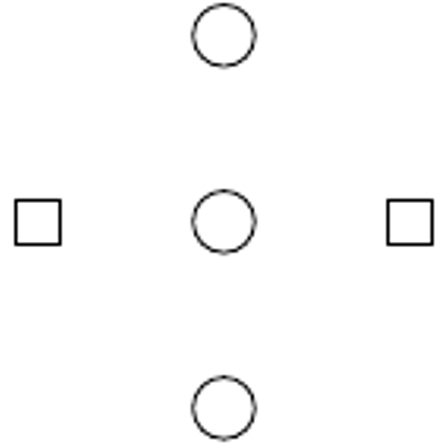

In [18]:
print(f"Used images: {len(sample):,}")
display(sample[0][IMAGE_COL])


### 3. CLIP-IMAGE-EMBEDDINGS


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = CLIPModel.from_pretrained(MODEL_ID).eval().to(device)


Device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 94810.76it/s]


In [20]:
def extract_image_features(model_output):
    """Support both tensor and ModelOutput return types."""
    if isinstance(model_output, torch.Tensor):
        return model_output

    for attribute in ("pooler_output", "image_embeds"):
        value = getattr(model_output, attribute, None)
        if isinstance(value, torch.Tensor):
            return value

    raise TypeError(
        "Unsupported CLIP output type: "
        f"{type(model_output).__name__}"
    )


all_embeddings = []

for start in tqdm(range(0, len(sample), BATCH_SIZE)):
    batch = sample[start : start + BATCH_SIZE]
    images = [image.convert("RGB") for image in batch[IMAGE_COL]]

    inputs = processor(images=images, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.inference_mode():
        output = model.get_image_features(pixel_values=pixel_values)
        features = extract_image_features(output)
        features = F.normalize(features.float(), dim=-1)

    all_embeddings.append(features.cpu().numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
print("Embedding matrix:", embeddings.shape)

np.save(f"{OUTPUT_PREFIX}_clip_embeddings.npy", embeddings)


100%|██████████| 4652/4652 [32:39<00:00,  2.37it/s]


Embedding matrix: (595447, 512)


### 4. PCA and Clustering

PCA and MiniBatchKMeans are fitted on the complete combined embedding matrix
when the benchmark dataset is enabled. Dataset membership does not influence
the clustering; it is retained only for analysis and later sampling.


In [21]:
n_components = min(50, embeddings.shape[0] - 1, embeddings.shape[1])

pca = PCA(n_components=n_components, random_state=SEED)
X = pca.fit_transform(embeddings)

clusterer = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=1024,
    n_init=10,
    random_state=SEED,
)
labels = clusterer.fit_predict(X)

print("PCA-Variance:", round(pca.explained_variance_ratio_.sum(), 3))


PCA-Variance: 0.718


### 5. Distribution of the clusters


dataset,benchmark,datikz,total,percent_total
cluster,,,,
0,40488,92584,133072,22.348253
1,23925,60727,84652,14.216547
2,56013,104360,160373,26.933212
3,47268,170082,217350,36.501989


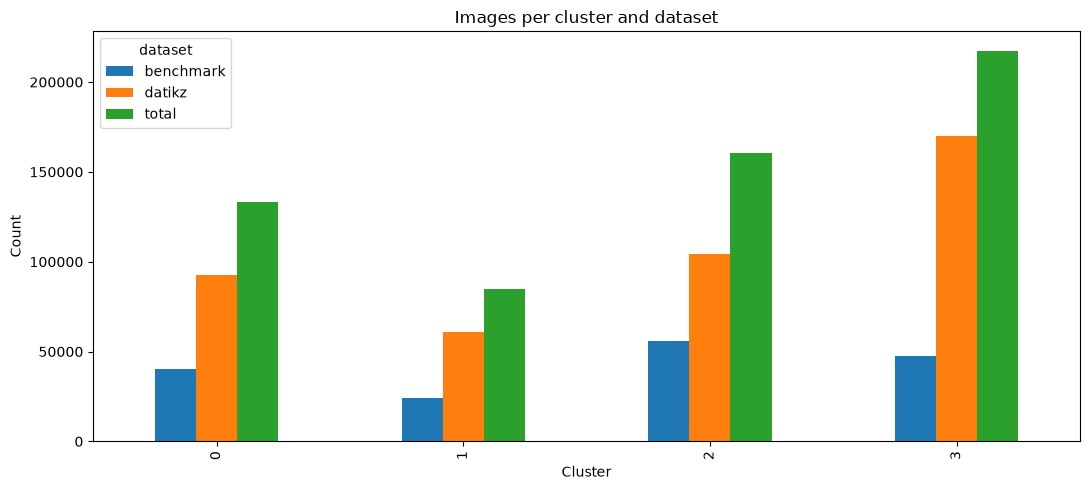

In [22]:
cluster_counts = (
    pd.DataFrame({
        "dataset": sample["dataset"],
        "cluster": labels,
    })
    .groupby(["cluster", "dataset"])
    .size()
    .unstack(fill_value=0)
)

cluster_counts["total"] = cluster_counts.sum(axis=1)
cluster_counts["percent_total"] = (
    100 * cluster_counts["total"] / len(labels)
)
display(cluster_counts)

cluster_counts.drop(columns="percent_total").plot.bar(
    figsize=(11, 5),
    title="Images per cluster and dataset",
    xlabel="Cluster",
    ylabel="Count",
)
plt.tight_layout()
plt.show()


### 6. Two-Dimensional Overview

This representation is only a rough projection. Overlapping points
do not necessarily mean that the clusters are poor.


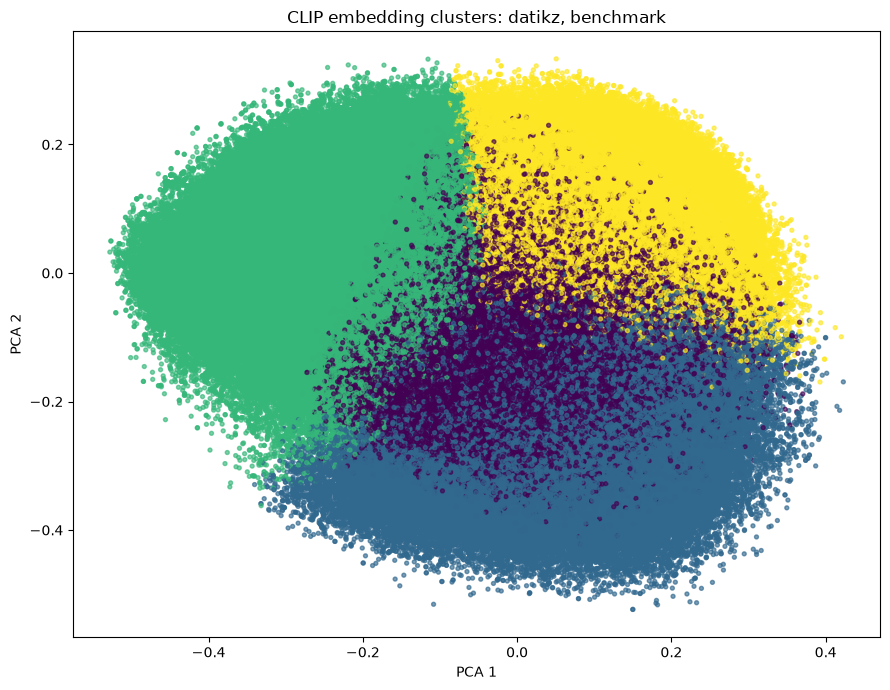

In [23]:
xy = PCA(n_components=2, random_state=SEED).fit_transform(X)

plt.figure(figsize=(9, 7))
plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=8, alpha=0.65)
plt.title(f"CLIP embedding clusters: {', '.join(DATASETS_TO_USE)}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()


### 6. Representative Examples per Cluster

The images shown are those with the smallest distance to the respective
cluster center. These are usually more meaningful than purely random examples.


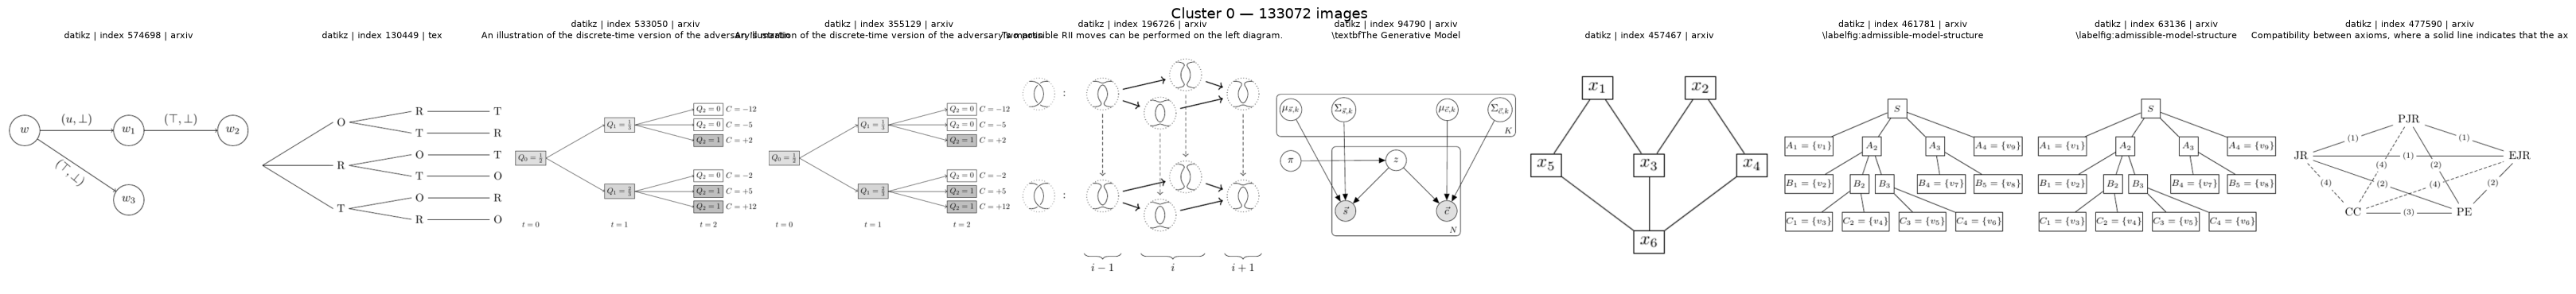

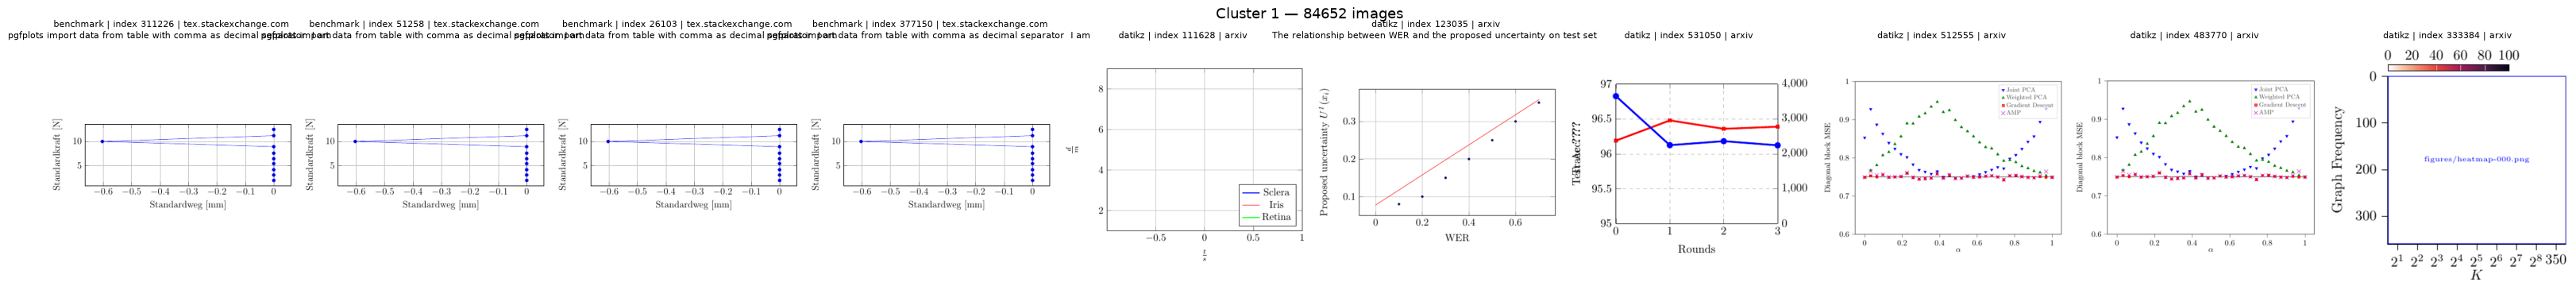

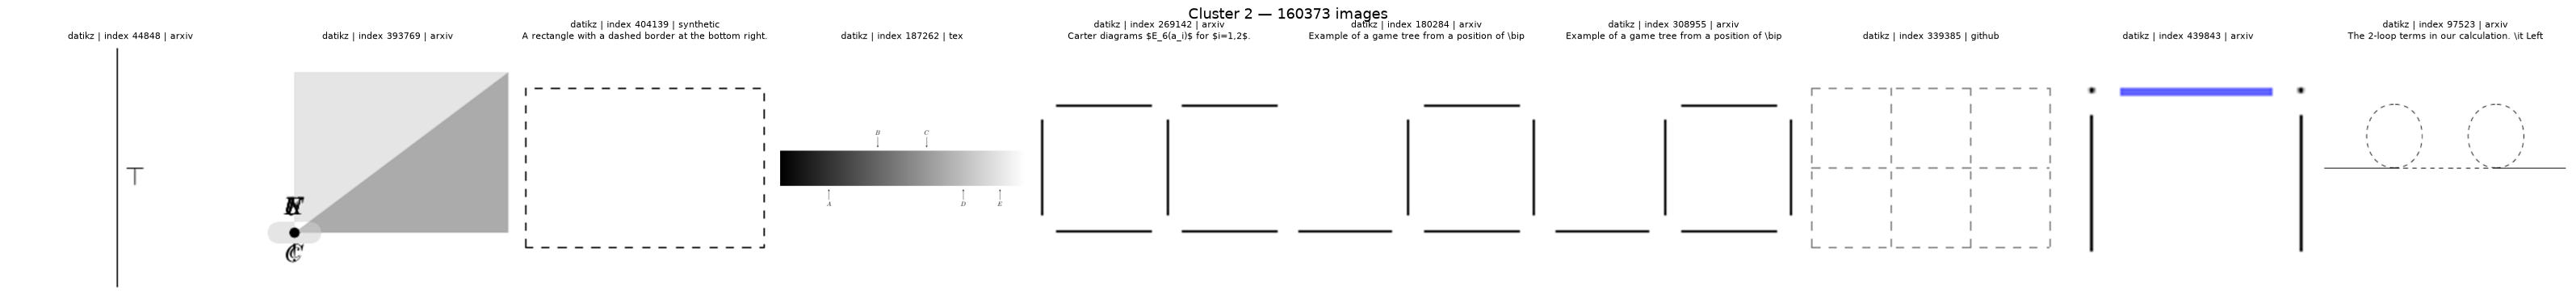

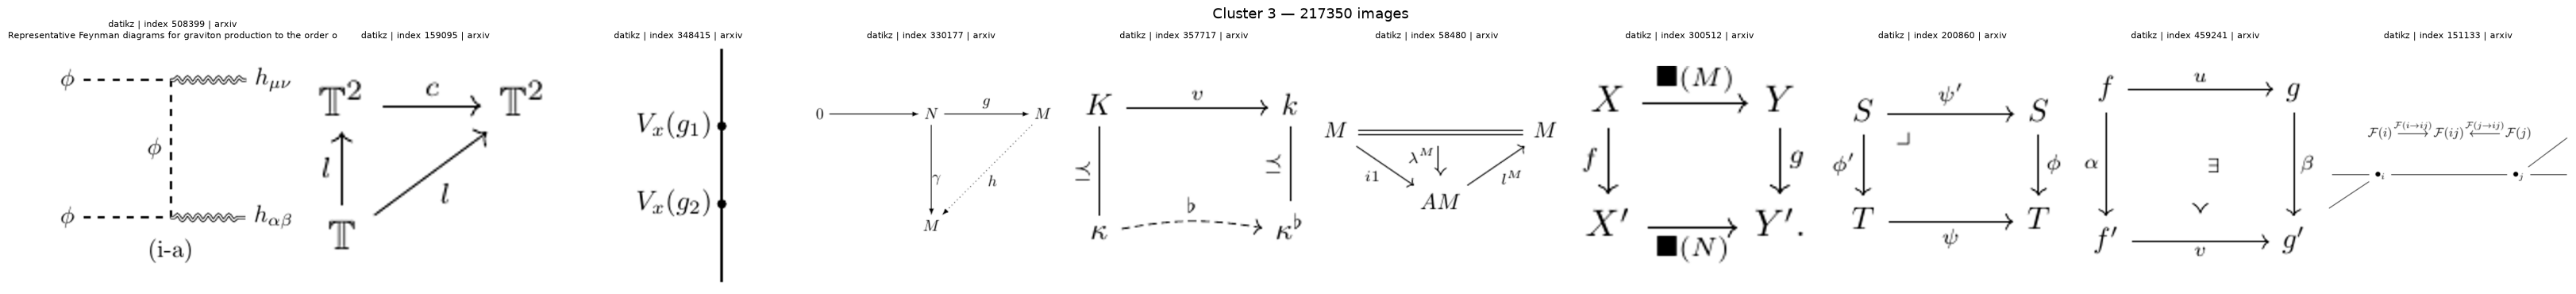

In [24]:
def show_cluster(cluster_id: int, n: int = 6):
    cluster_indices = np.where(labels == cluster_id)[0]

    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_id} is empty.")
        return

    distances = np.linalg.norm(
        X[cluster_indices] - clusterer.cluster_centers_[cluster_id],
        axis=1,
    )
    selected = cluster_indices[np.argsort(distances)[:n]]

    fig, axes = plt.subplots(
        1,
        len(selected),
        figsize=(3.2 * len(selected), 3.8),
    )
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, selected):
        row = sample[int(idx)]
        ax.imshow(row[IMAGE_COL])
        ax.axis("off")

        caption = str(row.get("caption", "") or "").replace("\n", " ")
        source = str(row.get("source", "") or "")
        dataset_name = str(row.get("dataset", ""))

        title = f"{dataset_name} | index {idx}"
        if source:
            title += f" | {source}"
        if caption:
            title += "\n" + caption[:70]

        ax.set_title(title, fontsize=8, parse_math=False)

    fig.suptitle(
        f"Cluster {cluster_id} — {len(cluster_indices)} images",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()


for cluster_id in range(N_CLUSTERS):
    show_cluster(cluster_id, n=10)


## 7. Name Clusters as Classes

After the visual review, add the names to the dictionary. The numeric
cluster IDs themselves have no semantic meaning.



In [25]:
cluster_names = {
    # Replace these examples after visual inspection:
    # 0: "Flowcharts",
    # 1: "Mathematical plots",
    # 2: "Geometric constructions",
}

results = pd.DataFrame({
    "sample_index": np.arange(len(sample)),
    "dataset": sample["dataset"],
    "sample_id": sample["sample_id"],
    "source": sample["source"],
    "cluster": labels,
})

results["class_name"] = results["cluster"].map(cluster_names)
results["class_name"] = results["class_name"].fillna(
    results["cluster"].map(lambda cluster: f"class_{cluster + 1}")
)

display(results.head())
display(
    pd.crosstab(
        results["class_name"],
        results["dataset"],
        margins=True,
    )
)

results.to_csv(
    f"{OUTPUT_PREFIX}_cluster_assignments.csv",
    index=False,
)


,sample_index,dataset,sample_id,source,cluster,class_name
0,0,datikz,datikz:lsst__rtn-063_converted_2270_33_4,github,2,class_3
1,1,datikz,datikz:synthetic_hard_751,synthetic,3,class_4
2,2,benchmark,benchmark:https://tex.stackexchange.com/a/451048,tex.stackexchange.com,2,class_3
3,3,datikz,datikz:tex_37161_0,tex,0,class_1
4,4,benchmark,benchmark:https://tex.stackexchange.com/a/624217,tex.stackexchange.com,0,class_1


dataset,benchmark,datikz,All
class_name,,,
class_1,40488,92584,133072
class_2,23925,60727,84652
class_3,56013,104360,160373
class_4,47268,170082,217350
All,167694,427753,595447


### Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster and how clearly it is separated from other clusters.

For each data point:

* (a) is the average distance to all other points in the same cluster.
* (b) is the average distance to the points in the nearest neighboring cluster.

The score is calculated as:

$$
s = \frac{b-a}{\max(a,b)}
$$

The resulting value ranges from **-1 to 1**:

* **Close to 1:** compact and well-separated clusters
* **Close to 0:** clusters overlap
* **Below 0:** the point may be assigned to the wrong cluster

The overall Silhouette Score is the average score across all data points.

The score is useful for comparing different numbers of clusters. For image data, it should be combined with visual inspection to check whether the clusters also represent meaningful image categories.


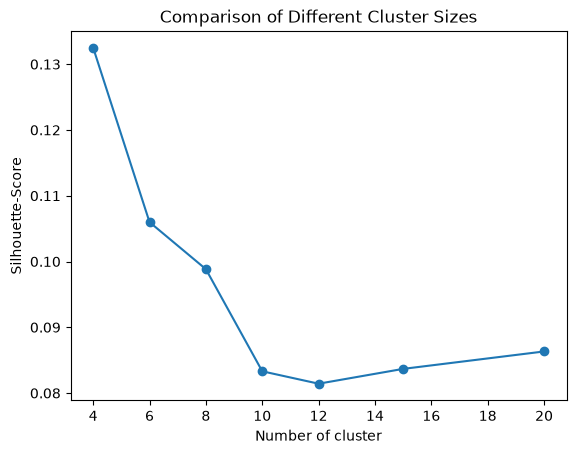

In [26]:
from sklearn.metrics import silhouette_score

scores = {}
rng = np.random.default_rng(SEED)
eval_indices = rng.choice(len(X), size=min(5_000, len(X)), replace=False)
X_eval = X[eval_indices]

for k in [4, 6, 8, 10, 12, 15, 20]:
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=1024,
        n_init=10,
        random_state=SEED,
    )
    eval_labels = km.fit_predict(X_eval)
    scores[k] = silhouette_score(X_eval, eval_labels)

pd.Series(scores, name="silhouette").plot(
    marker="o",
    xlabel="Number of cluster",
    ylabel="Silhouette-Score",
    title="Comparison of Different Cluster Sizes",
)
plt.show()
